<a href="https://colab.research.google.com/github/vighneshkhot10/CSL701-ce24_Machine-Learning-Lab/blob/main/exp2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Original DataFrame head:
    mpg  cylinders  displacement horsepower  weight  acceleration  model year  \
0  18.0          8         307.0        130    3504          12.0          70   
1  15.0          8         350.0        165    3693          11.5          70   
2  18.0          8         318.0        150    3436          11.0          70   
3  16.0          8         304.0        150    3433          12.0          70   
4  17.0          8         302.0        140    3449          10.5          70   

   origin                   car name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  

Original DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    flo

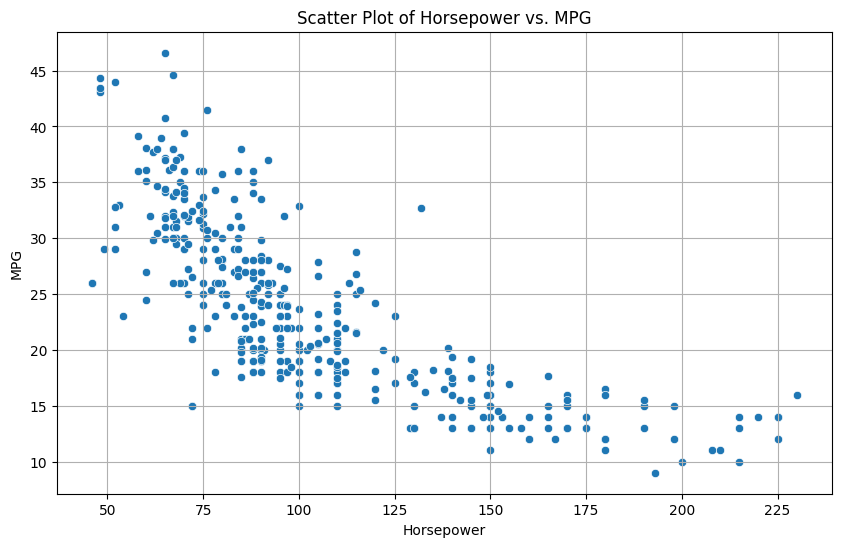


Shape of feature matrix with bias X_bias: (392, 2)
First 5 rows of X_bias:
[[  1. 130.]
 [  1. 165.]
 [  1. 150.]
 [  1. 150.]
 [  1. 140.]]

Correlation matrix between Horsepower and MPG:
            horsepower       mpg
horsepower    1.000000 -0.778427
mpg          -0.778427  1.000000

OLS Weights (beta coefficients): [39.93586102 -0.15784473]
Intercept (b0): 39.9359
Horsepower Coefficient (b1): -0.1578

Sum of Squared Errors (SSE): 9385.92
Mean Squared Error (MSE): 23.94
R-squared (R²): 0.6059


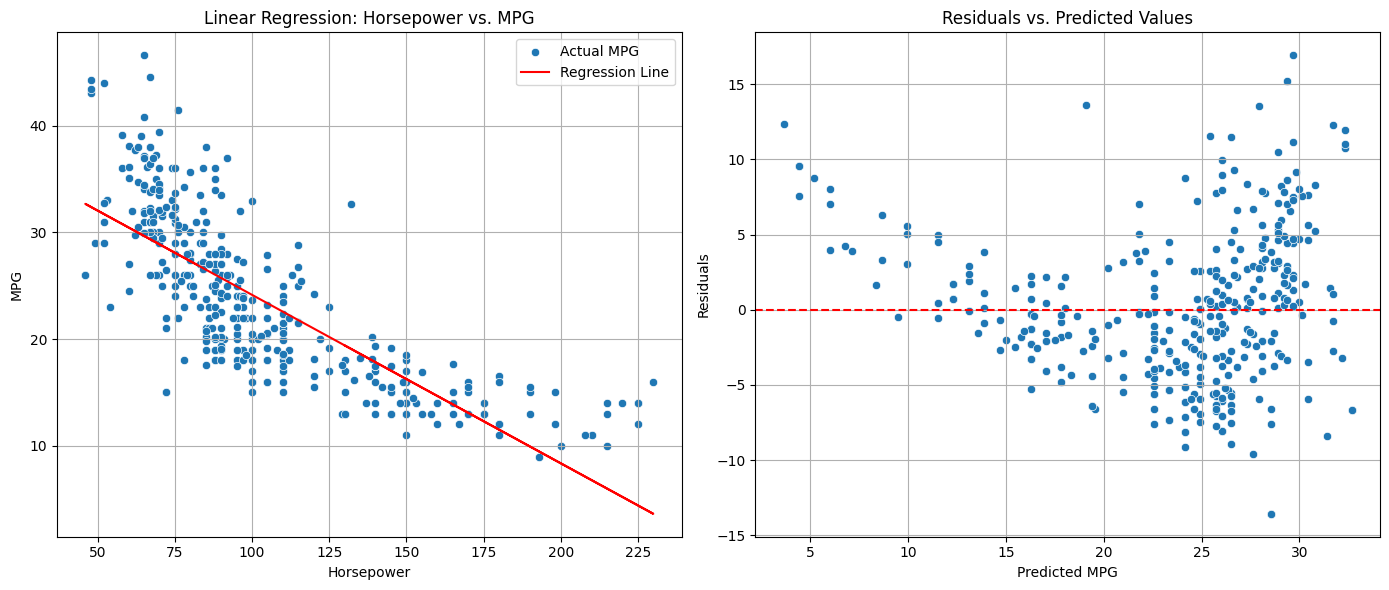


--- Interpretation of Results ---
The regression equation is: MPG = 39.94 + (-0.16 * Horsepower)
This means that for every one unit increase in horsepower, the MPG is expected to decrease by approximately 0.16 units.
The R-squared value of 0.6059 indicates that approximately 60.59% of the variance in MPG can be explained by horsepower.
The negative coefficient for horsepower suggests an inverse relationship: as horsepower increases, MPG tends to decrease.
The residuals plot shows if the model's errors are randomly distributed. Ideally, there should be no clear pattern.
The histogram of residuals should ideally approximate a normal distribution, centered around zero, suggesting the model assumptions are met.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Load Auto MPG dataset ---
pd.set_option('display.max_columns', None)
df = pd.read_csv('/content/auto-mpg.csv')

print('Original DataFrame head:')
print(df.head())
print('\nOriginal DataFrame info:')
df.info()

# --- 2. Inspect and clean data ---
# Handle '?' in horsepower column
df['horsepower'] = df['horsepower'].replace('?', np.nan)
df['horsepower'] = pd.to_numeric(df['horsepower'])

# Drop rows with any missing values, especially after handling '?'
df.dropna(inplace=True)

print('\nDataFrame head after cleaning:')
print(df.head())
print('\nDataFrame info after cleaning:')
df.info()
print('\nMissing values after cleaning:')
print(df.isnull().sum())

# --- 3. Select horsepower and mpg ---
X = df['horsepower'].values.reshape(-1, 1) # Feature
y = df['mpg'].values # Target

print(f'\nShape of feature X: {X.shape}')
print(f'Shape of target y: {y.shape}')

# --- 4. Plot scatter graph ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x='horsepower', y='mpg', data=df)
plt.title('Scatter Plot of Horsepower vs. MPG')
plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.grid(True)
plt.show()

# --- 5. Add bias term (intercept) to features ---
# Create design matrix X_b = [1 | X]
X_bias = np.c_[np.ones(X.shape[0]), X]

print(f'\nShape of feature matrix with bias X_bias: {X_bias.shape}')
print('First 5 rows of X_bias:')
print(X_bias[:5])

# --- 6. Compute correlation ---
correlation_matrix = df[['horsepower', 'mpg']].corr()
print('\nCorrelation matrix between Horsepower and MPG:')
print(correlation_matrix)

# --- 7. Calculate OLS weights (beta coefficients) ---
# Formula: beta = (X_bias_transpose * X_bias)_inverse * X_bias_transpose * y
# (X_bias.T @ X_bias)^-1 @ X_bias.T @ y
weights = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ y

intercept = weights[0]
horsepower_coeff = weights[1]

print(f'\nOLS Weights (beta coefficients): {weights}')
print(f'Intercept (b0): {intercept:.4f}')
print(f'Horsepower Coefficient (b1): {horsepower_coeff:.4f}')

# --- 8. Predict values ---
y_pred = X_bias @ weights

# --- 9. Compute residuals ---
residuals = y - y_pred

# --- 10. Calculate SSE, MSE, R² ---
n = len(y)

# Sum of Squared Errors (SSE)
SSE = np.sum(residuals**2)

# Mean Squared Error (MSE)
MSE = SSE / n

# Total Sum of Squares (TSS)
TSS = np.sum((y - y.mean())**2)

# R-squared (R²)
R_squared = 1 - (SSE / TSS)

print(f'\nSum of Squared Errors (SSE): {SSE:.2f}')
print(f'Mean Squared Error (MSE): {MSE:.2f}')
print(f'R-squared (R²): {R_squared:.4f}')

# --- 11. Plot regression and residual graphs ---
plt.figure(figsize=(14, 6))

# Plot 1: Regression Line
plt.subplot(1, 2, 1)
sns.scatterplot(x=df['horsepower'], y=df['mpg'], label='Actual MPG')
plt.plot(df['horsepower'], y_pred, color='red', label='Regression Line')
plt.title('Linear Regression: Horsepower vs. MPG')
plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.legend()
plt.grid(True)

# Plot 2: Residuals Plot
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted MPG')
plt.ylabel('Residuals')
plt.grid(True)

plt.tight_layout()
plt.show()

# --- 12. Interpret results ---
print('\n--- Interpretation of Results ---')
print(f'The regression equation is: MPG = {intercept:.2f} + ({horsepower_coeff:.2f} * Horsepower)')
print('This means that for every one unit increase in horsepower, the MPG is expected to decrease by approximately ' \
      f'{abs(horsepower_coeff):.2f} units.')
print(f'The R-squared value of {R_squared:.4f} indicates that approximately {R_squared*100:.2f}% of the variance in MPG can be explained by horsepower.')
print('The negative coefficient for horsepower suggests an inverse relationship: as horsepower increases, MPG tends to decrease.')
print("The residuals plot shows if the model's errors are randomly distributed. Ideally, there should be no clear pattern.")
print('The histogram of residuals should ideally approximate a normal distribution, centered around zero, suggesting the model assumptions are met.')